# Домашнее задание: Кластеризация текстов

Сеть супермаркетов «Перекрёсток» собирает отзывы от клиентов по разным каналам: мобильное приложение, сайт, чековые анкеты. Отзывы включают как положительные оценки, так и жалобы — на персонал, доставку, свежесть товаров, наличие и т.д.

**Бизнес сталкивается с проблемой**:

* Отзывов слишком много, они разнообразны по формулировкам.
* Ручная обработка отзывов — долгая и неэффективная.
* Нельзя быстро понять, о чём говорят клиенты, какие темы повторяются.

**Цель бизнеса**:

* Автоматически группировать отзывы по смыслу, чтобы:
* обнаруживать повторяющиеся проблемы (например, "не тот товар", "просрочка"),
* оценивать работу конкретных магазинов и доставок,
* поддерживать продуктовые и операционные улучшения на основе обратной связи.



In [1]:
!pip freeze > start_env.txt

# Читаем данные

Скачаем данные по отзывам на продукты. Предобработаем их и отфильтруем небольшое количество, чтобы потрогать руками различные алгоритмы, рассмотренные на лекции.

Для упрощения анализа кластеров и возможности здраво оценить, насколько результаты приемлемы, разделим данные на две явно разделенные по смыслу (во всяком случае, в среднем) группы: отзывы с максимальной оценкой и отзывы с минимальной оценкой.

In [2]:
# # помогает с ошибкой чтения датасета с HF
# !pip install fsspec==2023.6.0

In [3]:
import logging
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s", force=True)
logger = logging.getLogger(__name__)

In [4]:
from datasets import load_dataset

logging.getLogger("datasets").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)



# Загружаем train-часть датасета
dataset = load_dataset("lapki/perekrestok-reviews", split="train")
print(dataset)

2026-04-22 09:32:45,132 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Dataset({
    features: ['product_id', 'product_name', 'product_category', 'product_price', 'review_id', 'review_author', 'review_text', 'rating'],
    num_rows: 642682
})


In [5]:
from datasets import load_dataset
import pandas as pd

N = 10000
df = dataset.to_pandas()
df = df[["review_id", "product_category", "product_name", "review_text", "rating"]]
df = df.sort_values(by="review_id").head(N)
df.head(2)


,review_id,product_category,product_name,review_text,rating
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0


In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["clean_text"] = df["review_text"].apply(clean_text)
df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0,самые лучшие соки. всегда беру детям только их...
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0,"вкуснее, чем у известных конкурентов."


In [7]:
neg = df[df["rating"] == 1.0].sort_values(by="review_id")[:500]
pos = df[df["rating"] == 5.0].sort_values(by="review_id")[:500]
cut_df = pd.concat([neg, pos]).reset_index(drop=True)
cut_df["rating"].value_counts()

rating
1.0    500
5.0    500
Name: count, dtype: int64

In [8]:
cut_df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
0,3972,"Чай, кофе, сахар",Сахар песок белый 1кг,запекала сахар вместе с дыней. дыня совсем не ...,1.0,запекала сахар вместе с дыней. дыня совсем не ...
1,4462,"Чай, кофе, сахар",Кофе молотый Julius Meinl Prasident 250г,Почти без запаха.,1.0,почти без запаха.


# Алгоритмы визуализации - 5 баллов

Реализуйте функции для сжатия эмбеддингов до двумерного пространства с помощью подходов t-SNE и UMAP. Каждая функция должна строить изображения поданных на вход эмбеддингов в пространстве, а также учитывать, какое расстояние между эмбеддингами мы считаем (евклидово или косинусное).

Протестируйте их на небольшом семпле.

In [9]:
from typing import Any

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import umap

import seaborn as sns
from numpy.typing import NDArray

SEED = 20260421

# Можно реализовать через одну функцию, но для тестирования разных сетапов было удобно делать две отдельно


def plot_projection(projection: NDArray, title: str, scatter_kws):
    sns.set_style("whitegrid")
    _ = sns.relplot(
        x=projection[:, 0],
        y=projection[:, 1],
        kind="scatter",
        height=5,
        alpha=0.3,
        s=50,
        **scatter_kws,
    )
    plt.suptitle(title, y=1.05)
    plt.show()


# Визуализация через t-SNE
def plot_embeddings(
    embeds,
    title,
    metric="euclidean",
    random_state: int = SEED,
    reducer_kws: dict[str, Any] | None = None,
    scatter_kws: dict[str, Any] | None = None,
):
    reducer = TSNE(metric=metric, random_state=random_state, **(reducer_kws or {}))
    projection = reducer.fit_transform(X=embeds)
    plot_projection(projection, title, scatter_kws or {})


# Визуализация через UMAP
def plot_embeddings_umap(
    embeds,
    title,
    metric="euclidean",
    random_state: int = SEED,
    reducer_kws: dict[str, Any] | None = None,
    scatter_kws: dict[str, Any] | None = None,
):
    y = reducer_kws.pop("y", None) if reducer_kws else None
    reducer = umap.UMAP(metric=metric, random_state=random_state, **(reducer_kws or {}))
    projection = reducer.fit_transform(X=embeds, y=y)
    plot_projection(projection, title, scatter_kws or {})

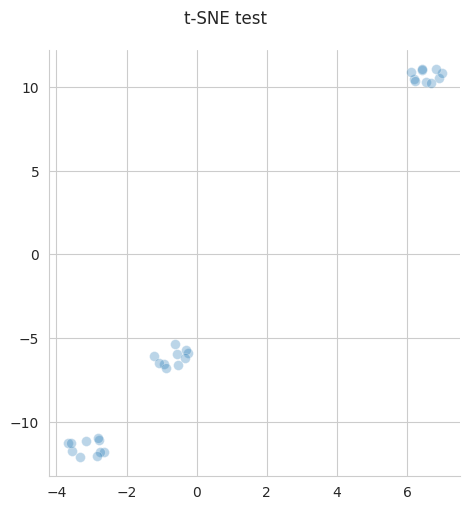

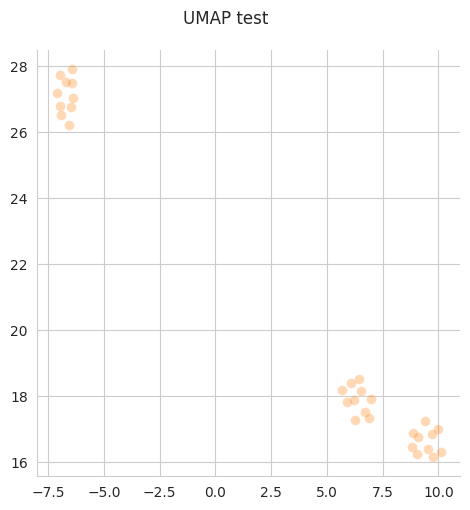

In [10]:
np.random.seed(SEED)

embs = np.concatenate([np.random.rand(10, 3), np.random.rand(10, 3) + 2, np.random.rand(10, 3) - 1], axis=0)

plot_embeddings(embs, "t-SNE test", metric="euclidean", reducer_kws={"perplexity": 10})
plot_embeddings_umap(embs, "UMAP test", metric="euclidean", reducer_kws={"n_jobs": 1}, scatter_kws={"color": "C1"})

# Зависимость кластеров от эмбеддера - 5 баллов

В данной части предлагается оценить, насколько эмбеддер на качество кластеризации может влиять:
а) эмбеддер
б) выбранная метрика расстояния

Возьмите следующие две модели:
1) "ai-forever/FRIDA" -- хороший качественный эмбеддер
2) "cointegrated/rubert-tiny2" -- достаточно слабый по современным меркам эмбеддер

Реализуйте подгрузку этой модели через класс SentenceTransformer и постройте визуализацию кластеров
а) через функцию с UMAP и через функцию с t-SNE
б) и для каждого варианта -- визуализацию с евклидовым расстоянием и с косинусным расстоянием
в) и для каждого варианта -- с эмбеддером FRIDA и с эмбеддером rubert-tiny2

Итого должно получиться 8 графиков. Сделайте выводы, какой эмбеддер визуально разграничивает данные лучше.

2026-04-22 09:33:06,657 - __main__ - INFO - Device: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


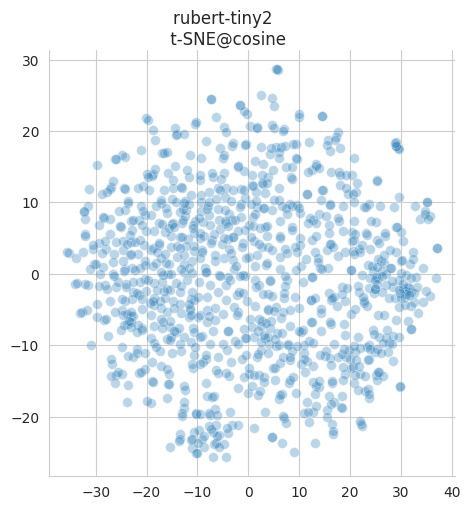

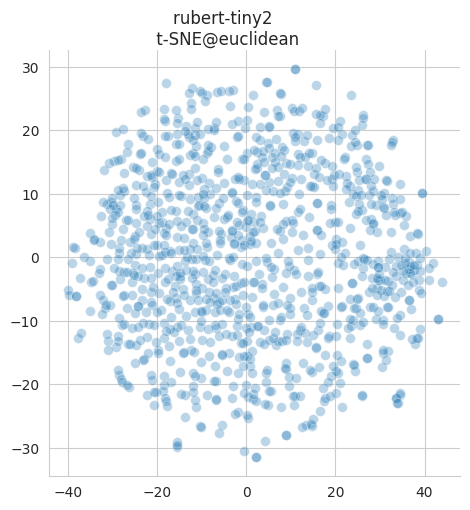

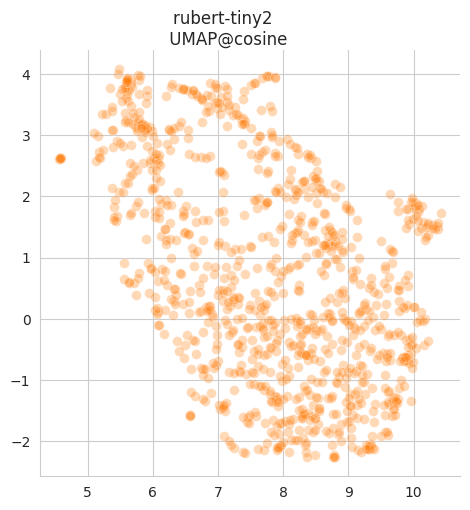

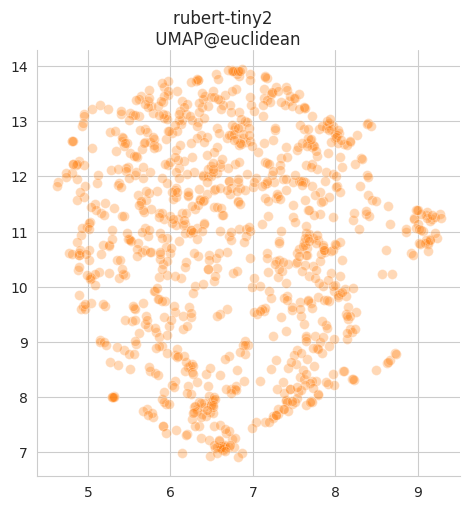

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

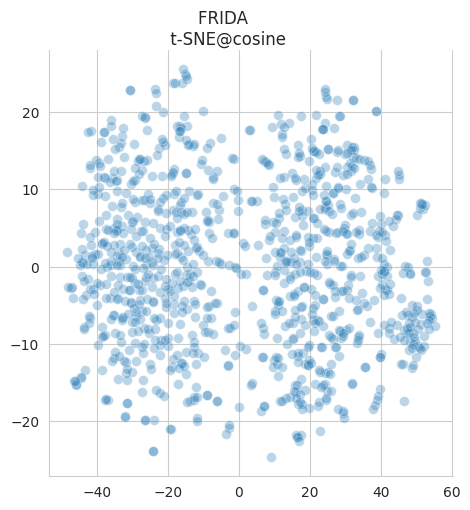

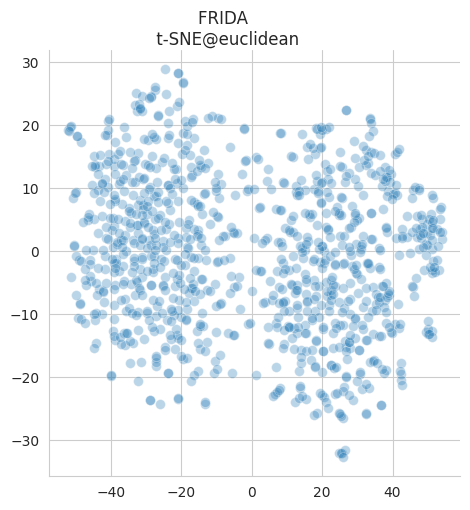

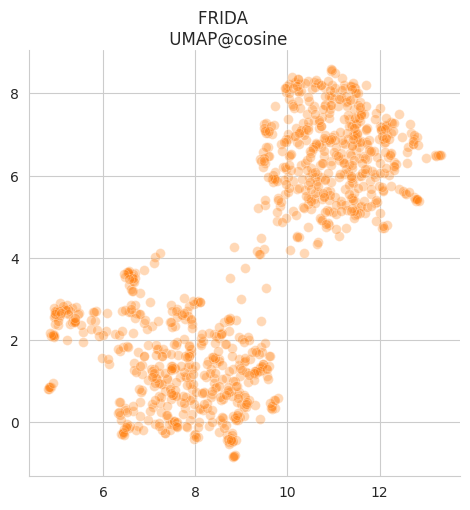

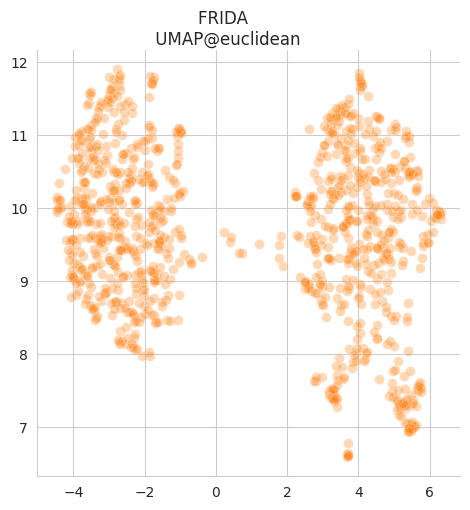

In [11]:
from sentence_transformers import SentenceTransformer
import torch


logging.getLogger("sentence_transformers").setLevel(logging.WARNING)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {DEVICE}")

texts = cut_df["clean_text"].values.tolist()


# ---- Ваш код здесь ----
def get_embeddings(
    model: SentenceTransformer,
    texts: list[str] = texts,
) -> NDArray:
    embs: NDArray = model.encode(
        texts,
        output_value="sentence_embedding",
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
        chunk_size=16,
        batch_size=16,
    )
    return embs


# Rubert
model_rubert = SentenceTransformer("cointegrated/rubert-tiny2", device=DEVICE)
embs_rubert = get_embeddings(model_rubert)
plot_embeddings(
    embs_rubert,
    title="rubert-tiny2 \n t-SNE@cosine",
    metric="cosine",
)
plot_embeddings(
    embs_rubert,
    title="rubert-tiny2 \n t-SNE@euclidean",
    metric="euclidean",
)
plot_embeddings_umap(
    embs_rubert,
    title="rubert-tiny2 \n UMAP@cosine",
    metric="cosine",
    reducer_kws={"min_dist": 0, "densmap": True, "dens_lambda": 0.05, "n_jobs": 1},
    scatter_kws={"color": "C1"},
)
plot_embeddings_umap(
    embs_rubert,
    title="rubert-tiny2 \n UMAP@euclidean",
    metric="euclidean",
    reducer_kws={"min_dist": 0, "densmap": True, "dens_lambda": 0.05, "n_jobs": 1},
    scatter_kws={"color": "C1"},
)


# FRIDA
model_frida = SentenceTransformer("ai-forever/FRIDA", device="cpu")
embs_frida = get_embeddings(model_frida)
plot_embeddings(
    embs_frida,
    title="FRIDA \n t-SNE@cosine",
    metric="cosine",
)
plot_embeddings(
    embs_frida,
    title="FRIDA \n t-SNE@euclidean",
    metric="euclidean",
)
plot_embeddings_umap(
    embs_frida,
    title="FRIDA \n UMAP@cosine",
    metric="cosine",
    reducer_kws={"n_jobs": 1},
    scatter_kws={"color": "C1"},
)
plot_embeddings_umap(
    embs_frida,
    title="FRIDA \n UMAP@euclidean",
    metric="euclidean",
    reducer_kws={"n_jobs": 1},
    scatter_kws={"color": "C1"},
)


**Вывод:**  
Эмбеддинги, полученные с помощью FRIDA, показали хорошую разделимость уже при параметрах по умолчанию, особенно на UMAP. В то время как убедительной видимой разделимости на RUBERT-TINY не удалось добиться даже с с достаточно агрессивным подбором параметров.

# Зависимость кластеров от алгоритма кластеризации - 10 баллов

Реализуйте кластеризацию выбранных нами текстов через алгоритмы KMeans, MiniBatchKMeans, HDBSCAN. Сравните эти алгоритмов визуально и по метрикам. В качестве метрик используйте silhouette_score для безотносительной оценки качества и adjusted_rand_score для оценки качества относительно рейтинга (1.0 или 5.0). Визуализацию делайте с помощью UMAP.

compare_clusterers принимает на вход кластеризуемые эмбеддинги и, опционально, референсные значения кластеров (в нашем случае -- принадлежность к рейтингу). Функция должна отрисовывать кластера в пространстве для трех алгоритмов и возвращать метрики по каждому из них в виде словаря.

In [12]:
from inspect import signature
from typing import Optional

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def compare_clusterers(
    embeddings: NDArray,
    true_labels: Optional[NDArray]=None,
    n_clusters: int = 5,
    random_state: int = SEED,
    reducer_kws: Optional[dict[str, Any]] = None,
):
    results = {}

    algs = {
        "kmeans": KMeans,
        "minibatchkmeans": MiniBatchKMeans,
        "hdbscan": HDBSCAN,
    }

    for alg, alg_fn in tqdm(algs.items()):
        logging.info(f"Algorithm: {alg} ...")
        
        params = {}
        params["random_state"] = random_state
        params["n_clusters"] = n_clusters
        params = {k: v for k, v in params.items() if k in signature(alg_fn).parameters}
        cls = alg_fn(**params).fit(embeddings)
        labels = cls.labels_
        
    
        # Metrics
        sil_score = silhouette_score(embeddings, labels, random_state=random_state)
        logging.info(f"Silhouette Score: {sil_score:.4f}")
        if true_labels is not None:
            ari_score = adjusted_rand_score(true_labels, labels)
            logging.info(f"Adjusted Rand Score: {ari_score:.4f}")
        else:
            ari_score = None
        
        results[alg] = {
            "silhouette_score": float(sil_score),
            "adjusted_rand_score": ari_score
        }

        # Plotting
        plot_embeddings_umap(
            embeddings,
            title=f"{alg} clusters",
            metric="euclidean",
            reducer_kws=reducer_kws,
            scatter_kws={"hue": labels, "palette": "tab10"},
        )

    return results

  0%|          | 0/3 [00:00<?, ?it/s]

2026-04-22 09:37:34,858 - root - INFO - Algorithm: kmeans ...
2026-04-22 09:37:35,055 - root - INFO - Silhouette Score: 0.0831
2026-04-22 09:37:35,061 - root - INFO - Adjusted Rand Score: 0.9024


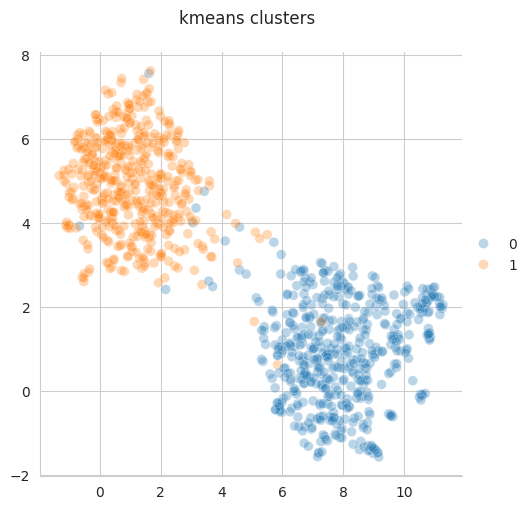

2026-04-22 09:37:37,925 - root - INFO - Algorithm: minibatchkmeans ...
2026-04-22 09:37:38,113 - root - INFO - Silhouette Score: 0.0831
2026-04-22 09:37:38,114 - root - INFO - Adjusted Rand Score: 0.9024


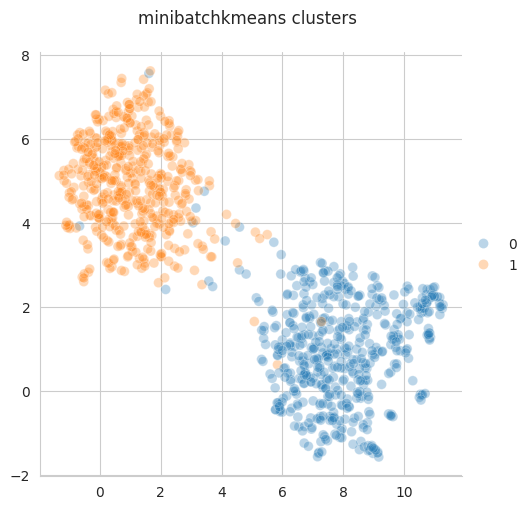

2026-04-22 09:37:40,983 - root - INFO - Algorithm: hdbscan ...
2026-04-22 09:37:43,750 - root - INFO - Silhouette Score: 0.0120
2026-04-22 09:37:43,752 - root - INFO - Adjusted Rand Score: 0.0036


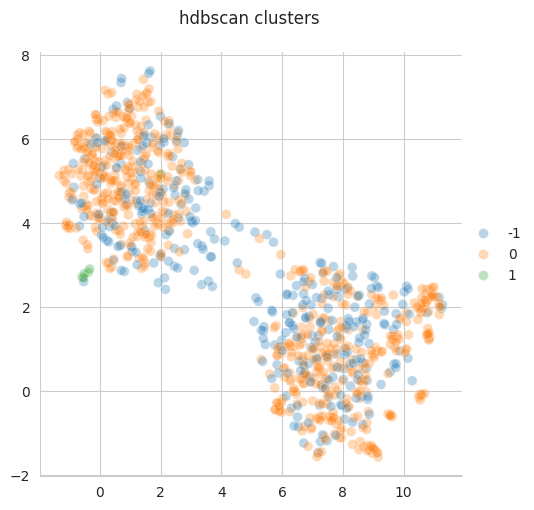

{'kmeans': {'silhouette_score': 0.08311696350574493,
  'adjusted_rand_score': 0.9024023519411439},
 'minibatchkmeans': {'silhouette_score': 0.08311696350574493,
  'adjusted_rand_score': 0.9024023519411439},
 'hdbscan': {'silhouette_score': 0.012001081369817257,
  'adjusted_rand_score': 0.00358543165195171}}

In [13]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

# good_embeds - берем наилучшие, т.е. от FRIDA
true_labels = (cut_df["rating"] == 5.0).apply(int).to_numpy()
results = compare_clusterers(
    embs_frida,
    true_labels=true_labels,
    n_clusters=2,
    reducer_kws={
        "n_neighbors": 100,
        "min_dist": 0.25,
        "densmap": True,
        "dens_lambda": 0.01,
        "dens_frac": 0.01,
        "set_op_mix_ratio": 0.1,
        "n_jobs": 1,
        "y": None,
    },
)
results

In [14]:
pd.DataFrame(results)

,kmeans,minibatchkmeans,hdbscan
silhouette_score,0.083117,0.083117,0.012001
adjusted_rand_score,0.902402,0.902402,0.003585


**Вывод:**  
Кластеризация по всем алгоритмам показывает близкий к нулю silhouette_score, т.е. кластера перекрываются - классы разделяются плохо.  
Хорошо отработали алгоритмы на KMeans по adjusted_rand_score, т.е. класс и кластер в большой части совпадают - визуально видно, что кластер 0 пространственно в правом скоплении, т.е. одна группа меток, и кластер 1 - в левом скоплении, другая группа меток.

# Интерпретируемость кластеров

## BERTopic - 5 баллов

Попробуем построить интерпретацию получаемых кластеров с помощью BERTopic, реализованного в виде отдельного фреймворка (строит кластера, считает c-TF-IDF, отбирает самые частотные и характеризующие кластер слова).

Если считать частотные слова напрямую, то в топе окажется много служебные слов, которые называют "стоп-словами". Игнорируйте эти слова при построении BERTopic -- это можно сделать с помощью переопределения vectorizer_model, заменив его на sklearn.CountVectorizer с использованием nltk stopwords.

In [15]:
# !pip install -q bertopic

In [16]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
# nltk.download()

# import plotly.io as pio
# pio.renderers.default = "notebook_connected"

from plotly.io import renderers
renderers.default = "notebook_connected" # интерактив в Jupyter/Colab

In [17]:

# ---- Ваш код здесь ----
print("стоп-слова и векторайзер")

embedding_model = model_frida
stop_words = stopwords.words("russian")
stop_words.extend(["это", "этот"])
vectorizer_model = CountVectorizer(stop_words=stop_words, max_features=10000)

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     language="russian",
#     calculate_probabilities=True,
#     verbose=False
# )

# ---- Конец кода ----

стоп-слова и векторайзер


In [18]:
# ---- Ваш код здесь ----
print(
    "вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова"
)


def rsc_cluster(
    texts: list[str] | NDArray,
    embs: NDArray,
) -> pd.DataFrame:
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        language="russian",
        calculate_probabilities=True,
        verbose=False
    )
    topics, probs = topic_model.fit_transform(texts, embs)
    df_topics = topic_model.get_topic_info()
    display(topic_model.visualize_barchart())
    return df_topics


df_topics_1 = rsc_cluster(
    np.array(texts)[true_labels == 0], embs_frida[true_labels == 0]
)

df_topics_5 = rsc_cluster(
    np.array(texts)[true_labels == 1], embs_frida[true_labels == 1]
)

# ---- Конец кода ----

вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова


![](topics_1.png)

![](topics_5.png)

In [20]:
df_topics_1

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14,-1_здоровья_вреден_одна_кальция,"[здоровья, вреден, одна, кальция, натрия, вред...","[кальция карбонат - вреден для здоровья, 5-риб..."
1,0,472,0_очень_вкус_запах_невозможно,"[очень, вкус, запах, невозможно, пришлось, про...",[ужасный фарш! при жарке появляется какая то п...
2,1,14,1_рис_плохой_запах_очень,"[рис, плохой, запах, очень, сыростью, скорее, ...",[рис действительно очень сильно пахнет плесень...


In [21]:
df_topics_5

,Topic,Count,Name,Representation,Representative_Docs
0,-1,216,-1_очень_вкусные_спасибо_вкус,"[очень, вкусные, спасибо, вкус, просто, хороши...",[мне очень нравится вкус этого кофе. и цена ра...
1,0,70,0_вкусный_очень_вкусно_сладкие,"[вкусный, очень, вкусно, сладкие, мандарины, в...","[вкусный растворимый, в меру сладкий. может, н..."
2,1,59,1_средство_рекомендую_запах_аромат,"[средство, рекомендую, запах, аромат, приятный...","[лучшее средство, отлично очищает, и запах ост..."
3,2,33,2_сыр_очень_хохланд_сыру,"[сыр, очень, хохланд, сыру, кефир, вкусный, тв...",[мы отдаем свое предпочтение только этому сыру...
4,3,23,3_вода_воду_застолья_родника,"[вода, воду, застолья, родника, берем, водичка...",[вода как с нашего родника в деревне! летом из...
5,4,22,4_очень_томаты_паста_сок,"[очень, томаты, паста, сок, состав, сока, поми...",[работаю шеф-поваром в ресторане. из дельных с...
6,5,20,5_картошечка_хорошая_отличная_морковка,"[картошечка, хорошая, отличная, морковка, разв...","[не люблю возиться с грязной картошкой, мыть е..."
7,6,19,6_молоко_масло_вкусное_такое,"[молоко, масло, вкусное, такое, кофе, магазине...","[молоко, как в детстве. очень вкусное. всегда ..."
8,7,14,7_мукой_мука_пирог_тесто,"[мукой, мука, пирог, тесто, маслом, такую, сма...","[давно использую эту муку и для блинов, и для ..."
9,8,14,8_огурцы_огурчики_сочные_хорошие,"[огурцы, огурчики, сочные, хорошие, отличные, ...","[огурцы отличные, сочные, свежие. спасибо!, хо..."


## Интерпретация через LLM - 15 баллов

Реализуйте интерпретацию кластеров с помощью LLM: кластеризуйте данные с помощью HDBSCAN, удалите аномалии (кластер -1), затем для каждого кластера насемплируйте 5-10 примеров.

Возьмите любую адекватную для русского языка LLM (например, saiga-yandexgpt из первой дз, либо для скорости можно взять qwen-2-0.5b -- хотя по качеству она будет достаточно слабой), и напишите к ней промпт, по которому данная ллм на основе семплированных отзывов должна написать короткое описание кластера.

В качестве результата выведите датафрейм, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.

In [47]:
cls = HDBSCAN(min_cluster_size=15).fit(embs_frida)
labels = cls.labels_

In [48]:
np.unique(labels, return_counts=True)

(array([-1,  0,  1]), array([823, 142,  35]))

In [49]:
n_samples = 10

samples_0 = np.random.default_rng(SEED).choice(
    np.array(texts)[labels == 0],
    n_samples
    )

samples_1 = np.random.default_rng(SEED).choice(
    np.array(texts)[labels == 1],
    n_samples
    )

input_task = "Кластер 0: {}. Кластер 1: {}".format(
    " ,".join(samples_0),
    " ,".join(samples_1),
)

input_task

'Кластер 0: отвратительная кукуруза. согласна с предыдущим отзывов. есть невозможно. на выброс. ребёнок от этой кукурузы начал чесаться((( ,кошмарное качество, при том, что пакеты на 35 л- при 10 л уже рвутся со всех сторон, каждый раз вся «прелесть» просыпается, кайфа в сборе мусора с пола не вижу никакого. не советую. ,кислятина, невозможно пить, да ещё и быстро выдыхается. мерзкий вкус, хуже не бывает. ,это трудно назвать мясом, тем более для плова. сплошные обрезки. жилки, не прожевать даже после двухчасовой готовки. запах неприятный. своеобразный запах отсутствует вовсе. для приготовления еды не рекомендую. ,ужасный фарш. воняет старым жиром. и столько из него жидкости при жарке вышло. просто ужас. больше не буду брать. ,отвратительно! жилы, жир и полусырое мясо. ,отвратительный фарш! мне кажется, что это даже вовсе не мясо, а просто какая то жирная белковая масса. уже многие написали о том, что после готовки всё буквально плавает в жиру. я такого давно не видела. плюс послевкусие

In [87]:
import openai
import os
from dotenv import load_dotenv


load_dotenv()

FOLDER_ID=os.environ["FOLDER_ID"]
API_KEY=os.environ["API_KEY"]
MODEL = "yandexgpt-5.1/latest"

promt = """
Ты эксперт по анализу отзывов. У меня есть кластеры отзывов о продуктах, товарах и сервисе магазина. Для каждого кластера:

1. Проанализируй предоставленные отзывы.
2. Дай краткое, лаконичное описание кластера.
3. Предложи название кластера (1–3 слова, яркое и запоминающееся).

Формат ответа: один json, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.
"""

client = openai.OpenAI(
    api_key=API_KEY,
    project=FOLDER_ID,
    base_url="https://ai.api.cloud.yandex.net/v1"
)

response = client.responses.create(
    model=f"gpt://{FOLDER_ID}/{MODEL}",
    input=input_task,
    instructions=promt,
    temperature=0.8,
    max_output_tokens=1500
)

In [88]:
ret = response.output[0].content[0].text

print(ret)

```
{
  "0": {
    "описание": "Пользователи крайне недовольны качеством продуктов: отмечают отвратительный вкус, плохое качество ингредиентов, проблемы с упаковкой и другие недостатки.",
    "название": "Негативные отзывы",
    "семпл": "отвратительная кукуруза. согласна с предыдущим отзывов. есть невозможно. на выброс. ребёнок от этой кукурузы начал чесаться((( ,кошмарное качество, при том, что пакеты на 35 л- при 10 л уже рвутся со всех сторон, каждый раз вся «прелесть» просыпается, кайфа в сборе мусора с пола не вижу никакого. не советую."
  },
  "1": {
    "описание": "Пользователи высоко оценивают качество товаров: отмечают хороший вкус, качественный состав, эффективность средств и удобство использования.",
    "название": "Позитивные отзывы",
    "семпл": "хорошее средство, прекрасно выполняет свою работу! ,очень вкусная томатная паста, без всяких консервантов. в составе помидоры. всегда беру только ее"
  }
}
```


In [97]:
# Распарсим ответ и выведем в удобном виде
import json

ret = ret.replace("\n", "").replace("'", '"').replace("`", "").replace("  ", "").replace("[", "").replace("]", "")
json_data = json.loads(ret)

pd.DataFrame(json_data)

,0,1
описание,Пользователи крайне недовольны качеством проду...,Пользователи высоко оценивают качество товаров...
название,Негативные отзывы,Позитивные отзывы
семпл,отвратительная кукуруза. согласна с предыдущим...,"хорошее средство, прекрасно выполняет свою раб..."


In [93]:
# # чистим cuda память
# import gc

# torch.cuda.empty_cache()
# torch.cuda.empty_cache()
# gc.collect()

In [94]:
# import pandas as pd
# import numpy as np
# import random
# from sentence_transformers import SentenceTransformer
# from sklearn.cluster import HDBSCAN
# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from sklearn.metrics.pairwise import cosine_distances
# pd.set_option("display.max_colwidth", None)


# # ---- Ваш код здесь ----
# print("реализуем семлпирование и разметку")
# # ---- Конец кода ----

# snorkel / flyingsquid - 10 баллов

В данном разделе предлагается воспользоваться фреймворком для semi-supervised кластеризации, в котором можно определить lf-функции, отображающие некоторые эвристики, и использовать их для автоматической доразметки данных. Необходимо написать как минимум 9 новых правдоподобных правил (то есть суммарно должно быть 10).

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант) -- шаблон кода под него расположен ниже

Для лучшего понимания интерфейса и функциональности предлагается ознакомиться с документацией фреймворков в сети.

In [ ]:
import numpy as np
import pandas as pd
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel


# df = pd.DataFrame({"text": texts})

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(embs_frida))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3


@labeling_function()
def lf_has_delivery_good_keywords(series):
    return (
        DELIVERY
        if any(
            w in series.text.lower()
            for w in [
                "доставка",
                "курьер",
                "привезли",
                "быстрый",
                "вовремя",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_delivery_bad_keywords(series):
    return (
        DELIVERY
        if any(
            w in series.text.lower()
            for w in [
                "доставка",
                "курьер",
                "медленный",
                "опоздал",
                "разбил",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_quality_good_keywords(series):
    return (
        QUALITY
        if any(
            w in series.text.lower()
            for w in [
                "качество",
                "хороший",
                "отличный",
                "нормальный",
                "свежий",
                "чистый",
                "эффективный",
                "прекрасный",
                "рекомендую",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_quality_bad_keywords(series):
    return (
        QUALITY
        if any(
            w in series.text.lower()
            for w in [
                "качество",
                "плохой",
                "ужасный",
                "просроченный",
                "старый",
                "гнилой",
                "грязный",
                "кошмарный",
                "плесень",
                "сырой",
                "отвратительный",
                "тухлый",
                "невозможный",
                "противный",
                "неприятный",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_service_keywords(series):
    return (
        SERVICE
        if any(
            w in series.text.lower()
            for w in [
                "сервис",
                "помощь",
                "поддержка",
                "обратная связь",
                "касса",
                "кассир",
                "услуга",
                "сборка",
                "готовый",
                "приложение",
                "программа",
                "чат",
                "ответ",
                "тишина",
                "шум",
                "удобный",
                "вежливый",
                "грубый",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_price_low_keywords(series):
    return (
        PRICE
        if any(
            w in series.text.lower()
            for w in [
                "цена",
                "дешево",
                "низкий",
                "скидка",
                "распродажа",
                "приемлемый",
            ]
        )
        else ABSTAIN
    )

@labeling_function()
def lf_has_price_high_keywords(series):
    return (
        PRICE
        if any(
            w in series.text.lower()
            for w in [
                "цена",
                "высокий",
                "дорого",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_delivery_pickup_keywords(series):
    return (
        DELIVERY
        if any(
            w in series.text.lower()
            for w in [
                "самовывоз",
                "пункт выдачи",
                "постамат",
                "выдача",
                "забрал",
                "получение",
                "забрать",
                "отправили",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_quality_packaging_keywords(series):
    return (
        QUALITY
        if any(
            w in series.text.lower()
            for w in [
                "упаковка",
                "упакован",
                "коробка",
                "пакет",
                "помятый",
                "поврежден",
                "разбитый",
                "целый",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_quality_product_match_keywords(series):
    return (
        QUALITY
        if any(
            w in series.text.lower()
            for w in [
                "брак",
                "подделка",
                "оригинал",
                "размер",
                "цвет",
                "описание",
                "фото",
                "комплектация",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_service_staff_keywords(series):
    return (
        SERVICE
        if any(
            w in series.text.lower()
            for w in [
                "продавец",
                "консультант",
                "сотрудник",
                "менеджер",
                "администратор",
                "персонал",
                "хамство",
                "невежливый",
            ]
        )
        else ABSTAIN
    )


@labeling_function()
def lf_has_price_payment_refund_keywords(series):
    return (
        PRICE
        if any(
            w in series.text.lower()
            for w in [
                "оплата",
                "оплатил",
                "чек",
                "возврат денег",
                "вернули деньги",
                "бонус",
                "кэшбек",
                "списали",
                "переплата",
            ]
        )
        else ABSTAIN
    )


lfs = [
    lf_has_delivery_good_keywords,
    lf_has_delivery_bad_keywords,
    lf_has_quality_good_keywords,
    lf_has_quality_bad_keywords,
    lf_has_service_keywords,
    lf_has_price_low_keywords,
    lf_has_price_high_keywords,
    lf_has_delivery_pickup_keywords,
    lf_has_quality_packaging_keywords,
    lf_has_quality_product_match_keywords,
    lf_has_service_staff_keywords,
    lf_has_price_payment_refund_keywords,
]
applier = PandasLFApplier(lfs)
L = applier.apply(df=df)

1000 1000


100%|██████████| 1000/1000 [00:02<00:00, 371.13it/s]


In [265]:
LFAnalysis(L=L, lfs=lfs).lf_summary()

,j,Polarity,Coverage,Overlaps,Conflicts
lf_has_delivery_good_keywords,0,[0],0.023,0.011,0.010
lf_has_delivery_bad_keywords,1,[0],0.002,0.002,0.001
lf_has_quality_good_keywords,2,[1],0.162,0.064,0.023
lf_has_quality_bad_keywords,3,[1],0.101,0.060,0.017
lf_has_service_keywords,4,[2],0.032,0.013,0.013
lf_has_price_low_keywords,5,[3],0.026,0.025,0.018
lf_has_price_high_keywords,6,[3],0.033,0.025,0.018
lf_has_delivery_pickup_keywords,7,[],0.000,0.000,0.000
lf_has_quality_packaging_keywords,8,[1],0.035,0.015,0.005
lf_has_quality_product_match_keywords,9,[1],0.033,0.017,0.008


In [267]:
label_model = LabelModel(cardinality=5, verbose=True)
label_model.fit(L_train=L, n_epochs=1000, log_freq=250, lr=1e-5, l2=5, seed=SEED)

2026-04-22 14:44:34,954 - root - INFO - Computing O...
2026-04-22 14:44:34,966 - root - INFO - Estimating \mu...
100%|██████████| 1000/1000 [00:03<00:00, 315.49epoch/s]
2026-04-22 14:44:38,144 - root - INFO - Finished Training


In [271]:
import polars as pl


probs = label_model.predict_proba(L=L)

pred_labels = probs.argmax(axis=1)
confidence = probs.max(axis=1)

has_lf_vote = (L != ABSTAIN).any(axis=1)

threshold = 0.75
pseudo_labels = np.where(
    has_lf_vote & (confidence >= threshold),
    pred_labels,
    ABSTAIN,
)

snorkel_df = pl.from_pandas(cut_df)
snorkel_df = (
    snorkel_df
    .with_columns(
        pl.Series("snorkel_label_id", pseudo_labels),
        pl.Series("snorkel_confidence", confidence),
        pl.Series("lf_votes_count", (L != ABSTAIN).sum(axis=1))
    )
    .with_columns(
        pl.when(pl.col("snorkel_label_id") == DELIVERY).then(pl.lit("delivery"))
        .when(pl.col("snorkel_label_id") == QUALITY).then(pl.lit("quality"))
        .when(pl.col("snorkel_label_id") == SERVICE).then(pl.lit("service"))
        .when(pl.col("snorkel_label_id") == PRICE).then(pl.lit("price"))
        .otherwise(pl.lit("abstain"))
        .alias("snorkel_label")
    )
)

(
    snorkel_df
    .filter(pl.col("snorkel_label") != "abstain")
    .group_by(
        "snorkel_label",
        "product_category", 
        )
    .agg(
        pl.len(), pl.col("review_text").sample(1)
        )
    .sort("len", descending=True)
    )

snorkel_label,product_category,len,review_text
str,str,u32,list[str]
"""quality""","""Овощи, фрукты, ягоды""",38,"[""Отличный и вкусный нектарин!!!!!!""]"
"""quality""","""Бытовая химия и гигиена""",25,"[""Лучшее средство, отлично очищает, и запах остается прекрасным. Цена хорошая. и ни как не влияет на качество товара. Рекомендую.""]"
"""quality""","""Макароны, крупы, специи""",25,"[""Тоже купила рис с запахом!!! По-всякому перепробовала готовить его, получается не вкусно. Понюхала упаковку с сырым рисом - ужасный запах непонятного чего.. Вдобавок меня еще обвинили в том, что я готовить не умею. Нельзя продавать такие продукты. ""]"
"""quality""","""Мясо, птица, колбасы""",25,"[""Ужас ! Такого я ещё не встречала !!! Хотелось приготовить плов , а получилось ужасное блюдо ! Эти кусочки жилистые не прожевать ! Запах кошмарный ! Жаль , что только сейчас обратила внимание на отзывы о данной продукции ((( ""]"
"""quality""","""Молоко, сыр, яйца""",23,"[""Увидела сегодня в магазине плакат «90 лет компании Hochland». И я подумала, это ли не показатель качества и стабильности производства. Я лично очень люблю именно эту марку сыра. Он низкокалорийный, нежный, без резких запахов, приятной консистенции. Я отдаю свое предпочтение плавленому сыру с зеленью! Состав отличный, делают его из натурального сыра. У меня проблемы с желудком и я внимательно отношусь к составу продукта. Хохланд с легкостью помогает мне держать диету. Я делаю себе пирамидки - хлебцы, сыр, овощи. Невероятно вкусно! ""]"
…,…,…,…
"""delivery""","""Сладости""",1,"[""Любимый торт семьи. Заказ привезли 5 августа. На этикетке стояла дата изготовления - 3 августа. 6 августа его и след простыл =) Вкусный орехово-ананасовый бисквит.""]"
"""price""","""Сладости""",1,"[""Внуки заценили! Было бы 20 звездочек, они бы поставили 30!""]"
"""price""","""Овощи, фрукты, ягоды""",1,"[""мандарины сладкие без косточек.плотные чистятся немного трудно.а тк\ак очень вкусно на мой вкус""]"


## flyingsquid - если хочется разнообразия 

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант)

Возможно, придется повозиться с установкой зависимостей в зависимости от среды -- ниже приведен необходимый набор установок для среды google colab.

In [1]:
!pip install -q flyingsquid
!pip3 install -q flyingsquid
!pip uninstall -y pgmpy
!pip install pgmpy==0.1.19
!pip3 install pgmpy==0.1.19
!pip install numpy==1.25

In [5]:
import numpy as np
import pandas as pd
from flyingsquid.label_model import LabelModel

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3

def lf_has_delivery_keywords(text):
    return DELIVERY if any(w in text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----




In [6]:
# ---- Ваш код здесь ----
print("запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты")
# ---- Конец кода ----




=== Кластер -1 ===
- Курьер опоздал на полчаса
- Очень быстрая доставка
- Привезли просроченное молоко
- Упаковка была рваная
- Все доставили вовремя
- Мясо испорчено, неприятный запах
- Курьер не предупредил о приезде
- Фрукты гнилые, явно старые
- Доставка порадовала — быстро и точно
- Сыр с плесенью, ужасный товар


/usr/local/lib/python3.11/dist-packages/pgmpy/models/MarkovModel.py:8: FutureWarning: MarkovModel has been renamed to MarkovNetwork. Please use MarkovNetwork class, MarkovModel will be removed in future.
  warnings.warn(


In [272]:
!pip freeze > end_env.txt